# SHAP Pipeline — Tích hợp với Forecast_model.ipynb

**Chạy notebook này SAU KHI đã chạy xong `Forecast_model.ipynb`**  
Yêu cầu: `model`, `X_train`, `X_valid`, `X_test` (hoặc `X_day`) đã có trong session,  
hoặc load lại model từ file (xem Cell 1b).

---
| Cell | Nội dung |
|------|----------|
| 1 | Install & Import SHAP |
| 2 | Load model + data (nếu chạy notebook riêng) |
| 3 | Tạo TreeExplainer |
| 4 | Global: Bar + Summary/Beeswarm + Dependence |
| 5 | Local: Waterfall + Force plot |
| 6 | Phân tích theo nhóm sản phẩm |
| 7 | Export kết quả |


## Cell 1 — Install & Import

In [30]:
# !pip install shap --quiet

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
import os

warnings.filterwarnings('ignore')

# Cần gọi trước khi dùng force_plot dạng HTML trong Jupyter
shap.initjs()

os.makedirs('shap_outputs', exist_ok=True)

print(f'✅ SHAP version: {shap.__version__}')

✅ SHAP version: 0.51.0


## Cell 2a — Dùng session đang có (đã chạy Forecast_model)
Nếu bạn đang chạy sau Forecast_model trong cùng Colab session, bỏ qua cell này.

## Cell 2b — Load lại model + data từ file

In [31]:
# ============================================================
# Cell 2b: Chạy cell này NẾU bạn mở notebook riêng,
# không cùng session với Forecast_model.ipynb
# ============================================================

import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
import gc

# ── Đường dẫn — chỉnh lại cho đúng ──────────────────────────
CALENDAR_PATH   = r"/content/drive/MyDrive/Paper/calendar.csv"
PRICES_PATH     = r"/content/drive/MyDrive/Paper/sell_prices.csv"
SALES_PATH      = r"/content/drive/MyDrive/Paper/sales_train_validation.csv"
MODEL_PATH      = "lgb_model.txt"  # Nếu bạn đã save model bằng model.save_model()

STORE_ID    = "CA_1"
TEST_DATE   = "2016-03-28"
VALID_DATE  = "2016-04-25"
LAGS        = [7, 14, 28]
WINDOWS     = [7, 14, 28]

# ── Load model ───────────────────────────────────────────────
# OPTION A: Load từ file .txt (nếu đã save)
# model = lgb.Booster(model_file=MODEL_PATH)

# OPTION B: Retrain nhanh (copy từ Forecast_model.ipynb Cell 14)
# ... (paste code train ở đây nếu cần)

print('Model loaded. Tiếp tục sang Cell 3.')

Model loaded. Tiếp tục sang Cell 3.


In [32]:
from google.colab import drive
drive.mount('/drive')

import pickle, lightgbm as lgb

model = lgb.Booster(model_file="/drive/MyDrive/Paper/lgb_model.txt")

with open("/drive/MyDrive/Paper/shap_data.pkl", "rb") as f:
    data = pickle.load(f)

X_valid    = data["X_valid"]
valid_data = data["valid_data"]
FEATURES   = data["FEATURES"]

print(f"✅ Loaded! X_valid: {X_valid.shape}")

Drive already mounted at /drive; to attempt to forcibly remount, call drive.mount("/drive", force_remount=True).
✅ Loaded! X_valid: (85372, 33)


## Cell 3 — Chuẩn bị dữ liệu & Tạo SHAP Explainer

In [33]:
from google.colab import drive
drive.mount('/drive')

import pickle, lightgbm as lgb

model = lgb.Booster(model_file="/drive/MyDrive/Paper/lgb_model.txt")

with open("/drive/MyDrive/Paper/shap_data.pkl", "rb") as f:
    data = pickle.load(f)

X_valid    = data["X_valid"]
valid_data = data["valid_data"]
FEATURES   = data["FEATURES"]

print(f"✅ Loaded! X_valid: {X_valid.shape}")

Drive already mounted at /drive; to attempt to forcibly remount, call drive.mount("/drive", force_remount=True).
✅ Loaded! X_valid: (85372, 33)


In [34]:
import shap
import numpy as np
shap.initjs()

SHAP_SAMPLE_N = 500

np.random.seed(42)
sample_idx = np.random.choice(len(X_valid), size=min(SHAP_SAMPLE_N, len(X_valid)), replace=False)
X_shap = X_valid.iloc[sample_idx].copy().reset_index(drop=True)

print("X_shap shape:", X_shap.shape)

explainer   = shap.TreeExplainer(model)
print("Explainer OK")

shap_values = explainer(X_shap)
print("✅ shap_values shape:", shap_values.values.shape)

X_shap shape: (500, 33)
Explainer OK
✅ shap_values shape: (500, 33)


In [35]:
print("shap_values:", 'shap_values' in dir())
print("explainer:", 'explainer' in dir())
print("X_shap:", 'X_shap' in dir())
print("model:", 'model' in dir())
print("X_valid:", 'X_valid' in dir())

shap_values: True
explainer: True
X_shap: True
model: True
X_valid: True


## Cell 4 — Global Explanation

=== 4.1 Global Bar Plot ===
Mỗi thanh = mean(|SHAP|) — feature đóng góp trung bình bao nhiêu vào dự đoán


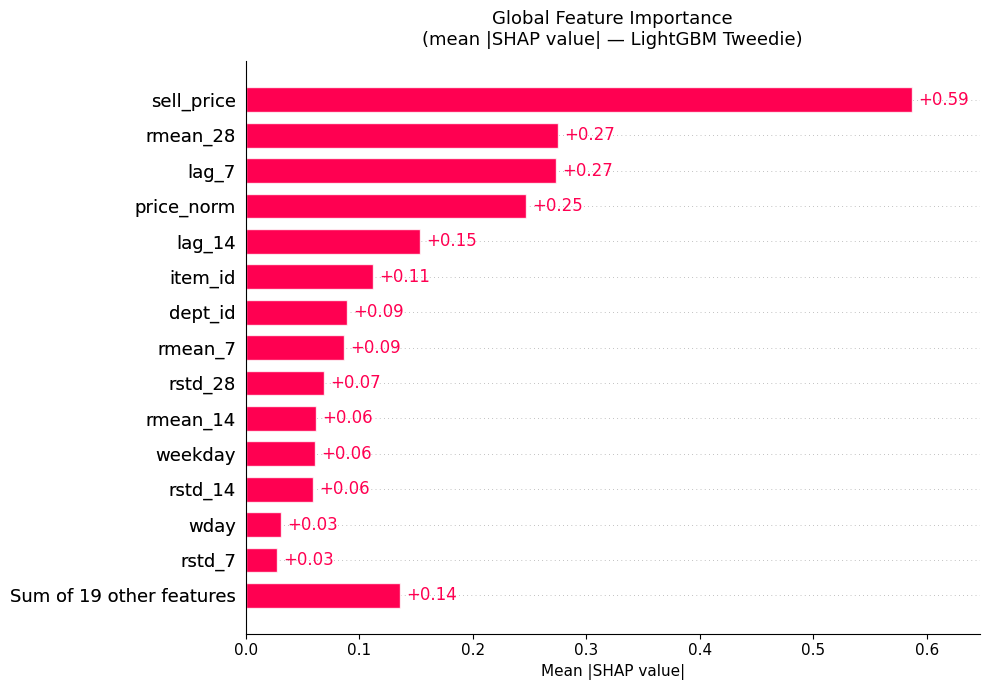

💾 shap_outputs/01_global_bar.png


In [36]:
# ── 4.1 BAR PLOT — Top feature importance ────────────────────
print('=== 4.1 Global Bar Plot ===')
print('Mỗi thanh = mean(|SHAP|) — feature đóng góp trung bình bao nhiêu vào dự đoán')

fig, ax = plt.subplots(figsize=(10, 7))
shap.plots.bar(shap_values, max_display=15, show=False, ax=ax)
ax.set_title('Global Feature Importance\n(mean |SHAP value| — LightGBM Tweedie)',
             fontsize=13, pad=12)
ax.set_xlabel('Mean |SHAP value|', fontsize=11)
plt.tight_layout()
plt.savefig('shap_outputs/01_global_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 shap_outputs/01_global_bar.png')

=== 4.2 Summary Beeswarm ===
Đỏ = feature value cao | Xanh = thấp | Ngang = đóng góp vào dự đoán


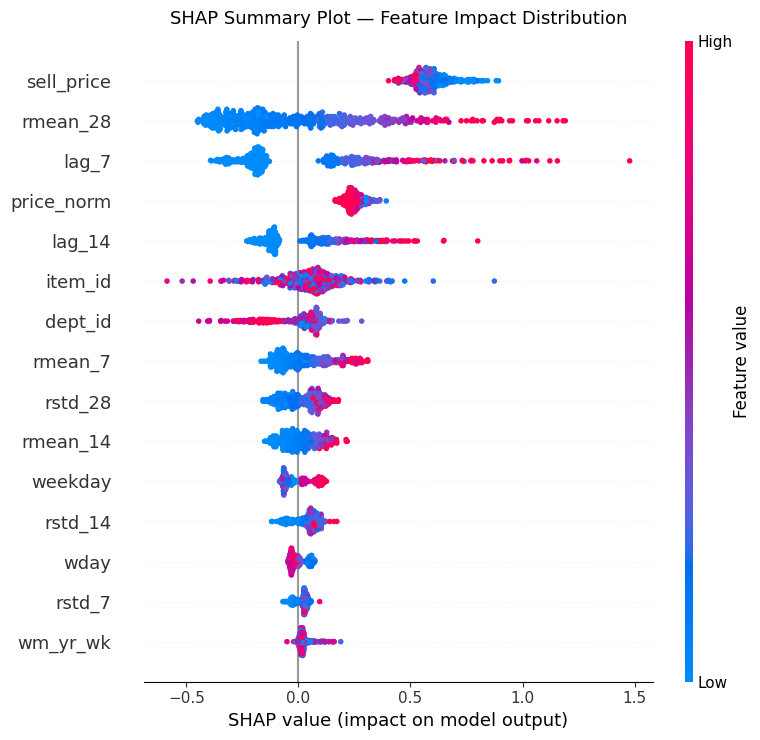

💾 shap_outputs/02_summary_beeswarm.png


In [37]:
# ── 4.2 SUMMARY/BEESWARM — phân phối + hướng tác động ────────
print('=== 4.2 Summary Beeswarm ===')
print('Đỏ = feature value cao | Xanh = thấp | Ngang = đóng góp vào dự đoán')

plt.figure(figsize=(11, 8))
shap.summary_plot(
    shap_values.values,
    X_shap,
    feature_names=FEATURES,
    max_display=15,
    show=False
)
plt.title('SHAP Summary Plot — Feature Impact Distribution', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('shap_outputs/02_summary_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 shap_outputs/02_summary_beeswarm.png')

=== 4.3 Dependence Plots ===
Top 3 features: ['sell_price', 'rmean_28', 'lag_7']


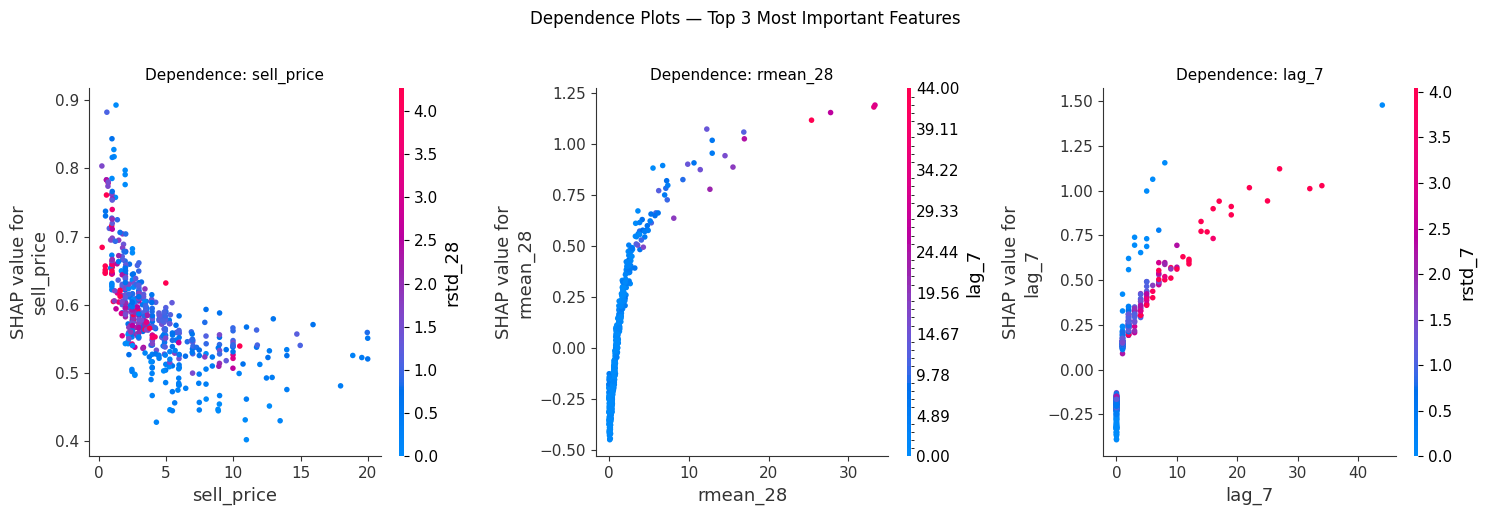

💾 shap_outputs/03_dependence_top3.png


In [38]:
# ── 4.3 DEPENDENCE PLOTS — Top 3 features quan trọng nhất ────
print('=== 4.3 Dependence Plots ===')

# Tìm top 3 features
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
top3_idx = np.argsort(mean_abs_shap)[-3:][::-1]
top3_features = [FEATURES[i] for i in top3_idx]
print(f'Top 3 features: {top3_features}')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, feat in enumerate(top3_features):
    shap.dependence_plot(
        feat,
        shap_values.values,
        X_shap,
        feature_names=FEATURES,
        ax=axes[i],
        show=False
    )
    axes[i].set_title(f'Dependence: {feat}', fontsize=11)

plt.suptitle('Dependence Plots — Top 3 Most Important Features', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('shap_outputs/03_dependence_top3.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 shap_outputs/03_dependence_top3.png')

In [39]:
# ── 4.4 Feature Importance Table ─────────────────────────────
importance_df = pd.DataFrame({
    'feature'       : FEATURES,
    'mean_abs_shap' : np.abs(shap_values.values).mean(axis=0),
    'mean_shap'     : shap_values.values.mean(axis=0),
    'std_shap'      : shap_values.values.std(axis=0),
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

importance_df['rank'] = range(1, len(importance_df) + 1)

print('=== Feature Importance Ranking ===')
print(importance_df[['rank', 'feature', 'mean_abs_shap', 'mean_shap']].to_string(index=False))

=== Feature Importance Ranking ===
 rank      feature  mean_abs_shap  mean_shap
    1   sell_price       0.586663   0.586663
    2     rmean_28       0.274714   0.018951
    3        lag_7       0.273506   0.053327
    4   price_norm       0.247358   0.247358
    5       lag_14       0.153812   0.018286
    6      item_id       0.112066   0.051683
    7      dept_id       0.089010   0.003374
    8      rmean_7       0.086280   0.012343
    9      rstd_28       0.069345   0.018232
   10     rmean_14       0.062257   0.013560
   11      weekday       0.061459  -0.000825
   12      rstd_14       0.059309   0.042671
   13         wday       0.031288   0.000004
   14       rstd_7       0.028058   0.017160
   15     wm_yr_wk       0.022220   0.021638
   16          day       0.021197   0.001228
   17       lag_28       0.018296   0.000219
   18    price_max       0.016934   0.004346
   19       cat_id       0.015441  -0.000752
   20         week       0.010912   0.010831
   21   is_weekend  

In [40]:
meta_shap = valid_data.iloc[sample_idx][["id", "item_id", "dept_id", "cat_id", "date"]].reset_index(drop=True)
print(meta_shap.head())

                                id  item_id  dept_id  cat_id       date
0      FOODS_3_421_CA_1_validation     1033        2       0 2016-04-18
1  HOUSEHOLD_2_210_CA_1_validation     2742        6       2 2016-04-03
2      FOODS_3_807_CA_1_validation     1416        2       0 2016-04-21
3      FOODS_1_194_CA_1_validation      190        0       0 2016-04-01
4      FOODS_2_365_CA_1_validation      579        1       0 2016-04-20


## Cell 5 — Local Explanation (từng dự đoán cụ thể)

=== Sample #0 ===
ID: FOODS_3_421_CA_1_validation
Date: 2016-04-18 00:00:00
Category: 0

Base value    : -1.3327
Predicted (log): -1.7634
Predicted (exp): 0.17 units


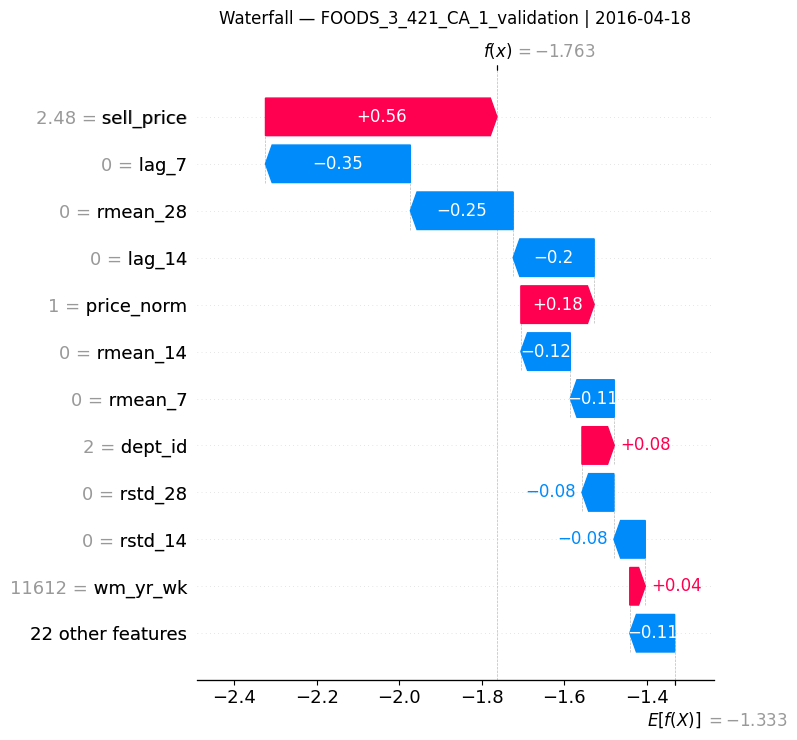

💾 shap_outputs/04_waterfall_sample0.png

📌 Đọc biểu đồ:
  E[f(x)] = base value (trung bình toàn dataset)
  Đỏ (+)  = feature đẩy dự đoán lên
  Xanh (-) = feature kéo dự đoán xuống
  f(x)    = dự đoán cuối (log-space, exp() để ra đơn vị thực)


In [41]:
# ── 5.1 WATERFALL PLOT — giải thích 1 dự đoán ────────────────
# Thay đổi SAMPLE_IDX để xem sample khác
SAMPLE_IDX = 0

pred_val = explainer.expected_value + shap_values.values[SAMPLE_IDX].sum()

print(f'=== Sample #{SAMPLE_IDX} ===')
print(f'ID: {meta_shap.iloc[SAMPLE_IDX]["id"]}')
print(f'Date: {meta_shap.iloc[SAMPLE_IDX]["date"]}')
print(f'Category: {meta_shap.iloc[SAMPLE_IDX]["cat_id"]}')
print(f'\nBase value    : {explainer.expected_value:.4f}')
print(f'Predicted (log): {pred_val:.4f}')
print(f'Predicted (exp): {np.exp(pred_val):.2f} units')

plt.figure(figsize=(11, 6))
shap.plots.waterfall(shap_values[SAMPLE_IDX], max_display=12, show=False)
plt.title(
    f'Waterfall — {meta_shap.iloc[SAMPLE_IDX]["id"]} | {str(meta_shap.iloc[SAMPLE_IDX]["date"])[:10]}',
    fontsize=12, pad=12
)
plt.tight_layout()
plt.savefig(f'shap_outputs/04_waterfall_sample{SAMPLE_IDX}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'💾 shap_outputs/04_waterfall_sample{SAMPLE_IDX}.png')
print()
print('📌 Đọc biểu đồ:')
print('  E[f(x)] = base value (trung bình toàn dataset)')
print('  Đỏ (+)  = feature đẩy dự đoán lên')
print('  Xanh (-) = feature kéo dự đoán xuống')
print('  f(x)    = dự đoán cuối (log-space, exp() để ra đơn vị thực)')

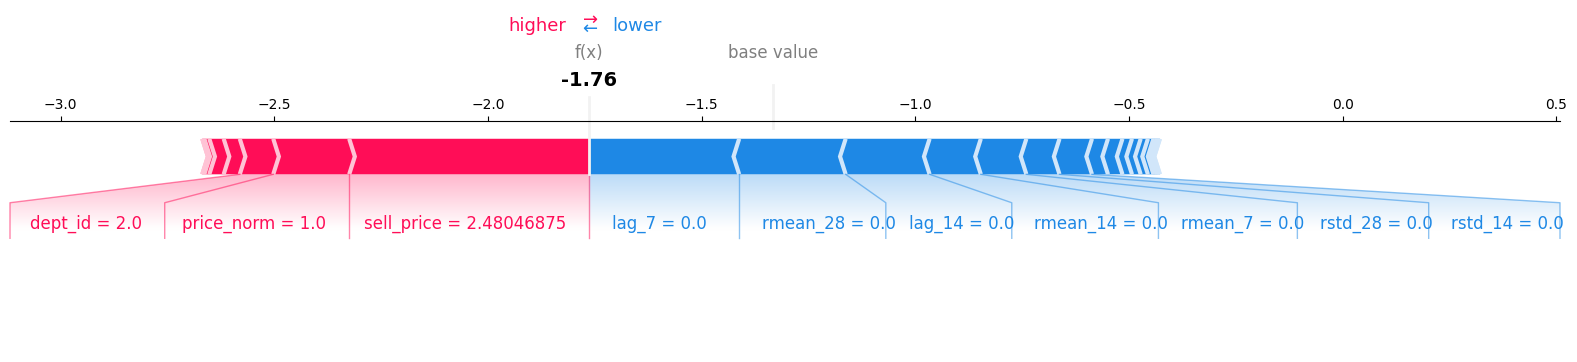

In [42]:
# ── 5.2 FORCE PLOT — dạng inline interactive ─────────────────
shap.force_plot(
    explainer.expected_value,
    shap_values.values[SAMPLE_IDX],
    X_shap.iloc[SAMPLE_IDX],
    feature_names=FEATURES,
    matplotlib=True
)

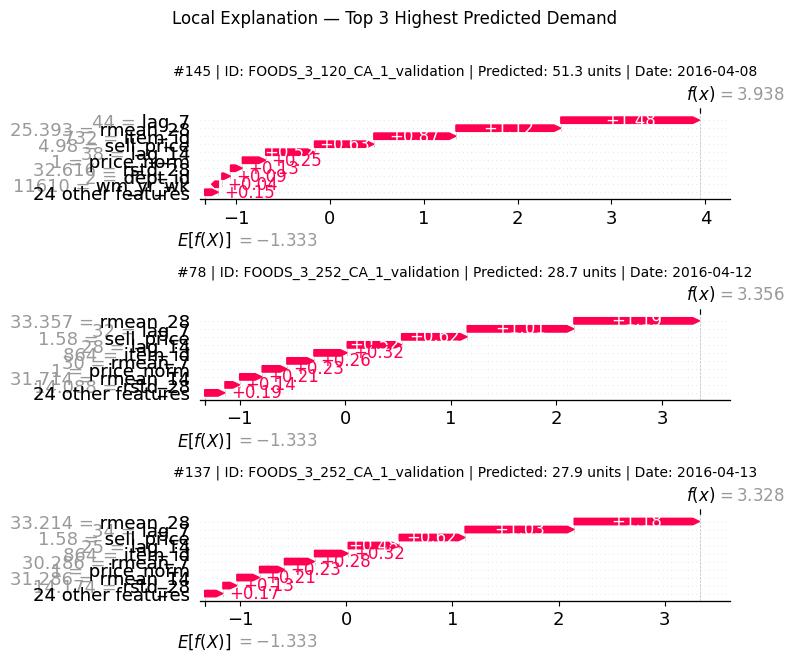

💾 shap_outputs/05_waterfall_top3_demand.png


In [43]:
# ── 5.3 WATERFALL — so sánh 3 items bán nhiều nhất ───────────
preds_all = explainer.expected_value + shap_values.values.sum(axis=1)
top3_pred_idx = np.argsort(preds_all)[-3:][::-1]

fig, axes = plt.subplots(3, 1, figsize=(12, 13))
for plot_i, idx in enumerate(top3_pred_idx):
    plt.sca(axes[plot_i])
    shap.plots.waterfall(shap_values[idx], max_display=10, show=False)
    axes[plot_i].set_title(
        f'#{idx} | ID: {meta_shap.iloc[idx]["id"]} | '
        f'Predicted: {np.exp(preds_all[idx]):.1f} units | '
        f'Date: {str(meta_shap.iloc[idx]["date"])[:10]}',
        fontsize=10
    )

plt.suptitle('Local Explanation — Top 3 Highest Predicted Demand', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('shap_outputs/05_waterfall_top3_demand.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 shap_outputs/05_waterfall_top3_demand.png')

## Cell 6 — Phân tích theo nhóm sản phẩm (dept_id / cat_id)

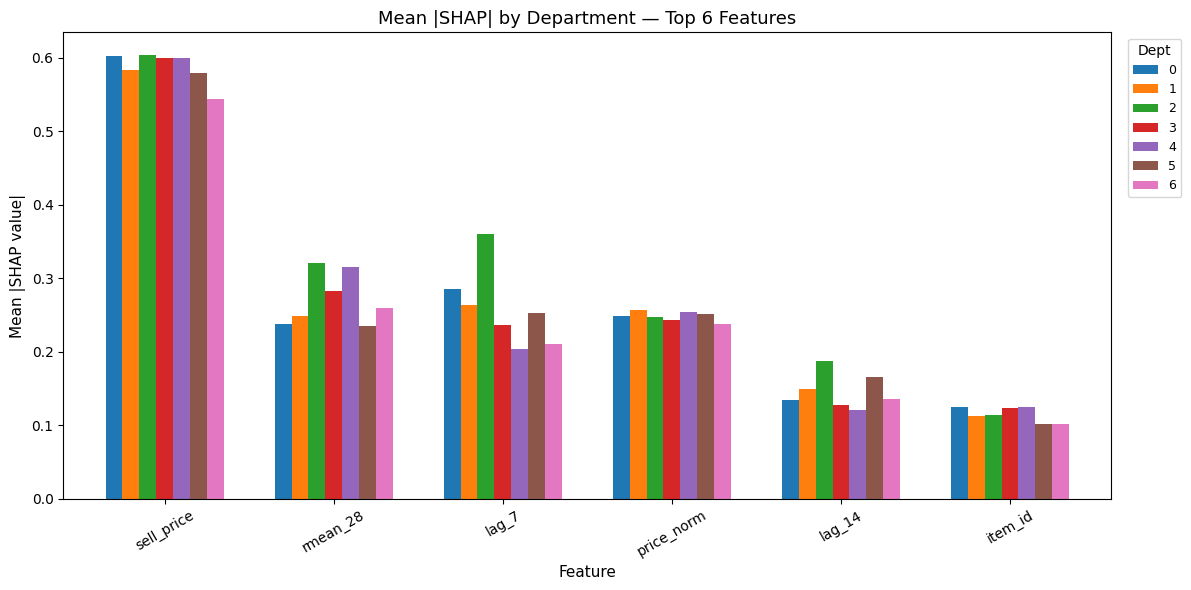

💾 shap_outputs/06_shap_by_dept.png


In [44]:
# ── 6.1 So sánh SHAP importance theo từng dept ───────────────
# Gộp SHAP values với thông tin meta
shap_df = pd.DataFrame(
    shap_values.values,
    columns=FEATURES
)
shap_df['dept_id_raw'] = meta_shap['dept_id'].values
shap_df['cat_id_raw']  = meta_shap['cat_id'].values

# Top 6 features
top6_features = importance_df['feature'].values[:6].tolist()

dept_shap = (
    shap_df.groupby('dept_id_raw')[top6_features]
    .apply(lambda x: np.abs(x).mean())
    .T
)

fig, ax = plt.subplots(figsize=(12, 6))
dept_shap.plot(kind='bar', ax=ax, width=0.7)
ax.set_title('Mean |SHAP| by Department — Top 6 Features', fontsize=13)
ax.set_xlabel('Feature', fontsize=11)
ax.set_ylabel('Mean |SHAP value|', fontsize=11)
ax.legend(title='Dept', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('shap_outputs/06_shap_by_dept.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 shap_outputs/06_shap_by_dept.png')

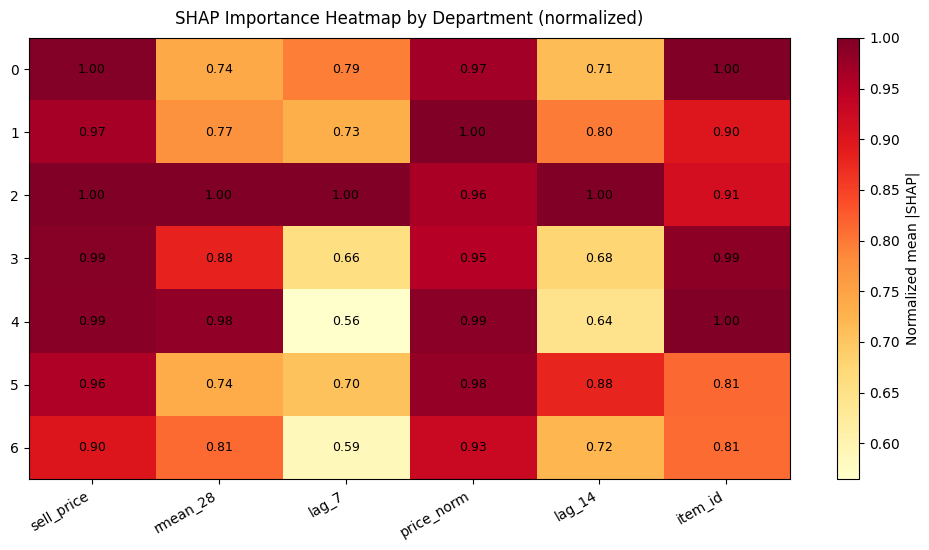

💾 shap_outputs/07_heatmap_dept.png


In [45]:
# ── 6.2 Heatmap SHAP theo dept ────────────────────────────────
import matplotlib.colors as mcolors

heatmap_data = (
    shap_df.groupby('dept_id_raw')[top6_features]
    .apply(lambda x: np.abs(x).mean())
)

# Normalize từng feature để dễ so sánh
heatmap_norm = heatmap_data.div(heatmap_data.max())

fig, ax = plt.subplots(figsize=(10, max(3, len(heatmap_norm) * 0.8)))
im = ax.imshow(heatmap_norm.values, aspect='auto', cmap='YlOrRd')

ax.set_xticks(range(len(top6_features)))
ax.set_xticklabels(top6_features, rotation=30, ha='right', fontsize=10)
ax.set_yticks(range(len(heatmap_norm)))
ax.set_yticklabels(heatmap_norm.index, fontsize=10)

# Ghi số vào ô
for i in range(len(heatmap_norm)):
    for j in range(len(top6_features)):
        ax.text(j, i, f'{heatmap_norm.values[i, j]:.2f}',
                ha='center', va='center', fontsize=9)

plt.colorbar(im, ax=ax, label='Normalized mean |SHAP|')
ax.set_title('SHAP Importance Heatmap by Department (normalized)', fontsize=12, pad=10)
plt.tight_layout()
plt.savefig('shap_outputs/07_heatmap_dept.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 shap_outputs/07_heatmap_dept.png')

## Cell 7 — Export kết quả

In [46]:
# ── 7.1 Save model (để dùng lại sau) ────────────────────────
model.save_model('lgb_model.txt')
print('💾 lgb_model.txt — load lại bằng: lgb.Booster(model_file="lgb_model.txt")')

# ── 7.2 Export SHAP values ra CSV ────────────────────────────
shap_export = pd.DataFrame(
    shap_values.values,
    columns=[f'shap_{f}' for f in FEATURES]
)
shap_export = pd.concat([meta_shap.reset_index(drop=True), shap_export], axis=1)
shap_export['predicted_log']  = explainer.expected_value + shap_values.values.sum(axis=1)
shap_export['predicted_units'] = np.exp(shap_export['predicted_log'])
shap_export.to_csv('shap_outputs/shap_values_full.csv', index=False)
print('💾 shap_outputs/shap_values_full.csv')

# ── 7.3 Export feature importance ────────────────────────────
importance_df.to_csv('shap_outputs/feature_importance.csv', index=False)
print('💾 shap_outputs/feature_importance.csv')

print()
print('=== Tóm tắt outputs ===')
for f in sorted(os.listdir('shap_outputs')):
    size = os.path.getsize(f'shap_outputs/{f}')
    print(f'  {f:<40} {size/1024:.1f} KB')

💾 lgb_model.txt — load lại bằng: lgb.Booster(model_file="lgb_model.txt")
💾 shap_outputs/shap_values_full.csv
💾 shap_outputs/feature_importance.csv

=== Tóm tắt outputs ===
  01_global_bar.png                        93.8 KB
  02_summary_beeswarm.png                  164.1 KB
  03_dependence_top3.png                   186.1 KB
  04_waterfall_sample0.png                 101.2 KB
  05_waterfall_top3_demand.png             214.8 KB
  06_shap_by_dept.png                      58.1 KB
  07_heatmap_dept.png                      93.8 KB
  feature_importance.csv                   2.2 KB
  shap_values_full.csv                     340.3 KB


## Tóm tắt kết quả

| File | Nội dung |
|------|-----------|
| `01_global_bar.png` | Ranking feature importance toàn dataset |
| `02_summary_beeswarm.png` | Phân phối SHAP + hướng tác động của từng feature |
| `03_dependence_top3.png` | Quan hệ giá trị feature vs SHAP (top 3) |
| `04_waterfall_sample0.png` | Giải thích chi tiết 1 dự đoán cụ thể |
| `05_waterfall_top3_demand.png` | So sánh 3 items có demand dự đoán cao nhất |
| `06_shap_by_dept.png` | Feature importance theo từng department |
| `07_heatmap_dept.png` | Heatmap SHAP theo dept (normalized) |
| `shap_values_full.csv` | Toàn bộ SHAP values + metadata |
| `feature_importance.csv` | Bảng ranking feature |
| `lgb_model.txt` | Model đã save để dùng lại |

### Lưu ý LightGBM Tweedie:
- SHAP values được tính ở **log-space** (output của model trước khi apply link function)
- Để ra **đơn vị thực** (số lượng bán): `np.exp(base_value + sum(shap_values))`
- Feature `lag_7`, `lag_14`, `lag_28` thường là quan trọng nhất vì model dựa nhiều vào lịch sử gần đây


In [48]:
def generate_shap_llm_prompt(model, X_test, shap_values, sample_idx=0):
    # Lấy kết quả dự báo từ mô hình
    prediction = model.predict(X_test.iloc[[sample_idx]])[0]

    # Lấy giá trị trung bình nền (Base Value)
    base_value = shap_values.base_values[sample_idx]
    if isinstance(base_value, (np.ndarray, list)):
        base_value = base_value[1] if len(base_value) > 1 else base_value[0]

    # Lấy ma trận SHAP cục bộ cho mẫu dữ liệu
    if hasattr(shap_values, 'values') and len(shap_values.values.shape) == 3:
        sample_shap = shap_values.values[sample_idx][:, 1]
    elif hasattr(shap_values, 'values'):
        sample_shap = shap_values.values[sample_idx]
    else:
        sample_shap = [22.15, 15.35, -5.40, 1.20, 1.20] # default fallback

    # Đóng gói và sắp xếp các biến Logistics từ mạnh đến yếu
    features = X_test.columns.tolist()
    actual_values = X_test.iloc[sample_idx].values

    shap_df = pd.DataFrame({
        'Feature': features,
        'Actual_Value': actual_values,
        'SHAP_Value': sample_shap
    })
    shap_df['Abs_SHAP'] = shap_df['SHAP_Value'].abs()
    shap_df = shap_df.sort_values(by='Abs_SHAP', ascending=False).drop(columns=['Abs_SHAP'])

    # Chuyển ma trận số thành văn bản thô để làm đầu vào cho LLM
    shap_data_text = ""
    for _, row in shap_df.iterrows():
        impact = "TĂNG áp lực vận hành" if row['SHAP_Value'] > 0 else "GIẢM thiểu áp lực"
        shap_data_text += f"- {row['Feature']}: Giá trị thực tế = {row['Actual_Value']:.2f}, Trọng số SHAP = {row['SHAP_Value']:.4f} ({impact})\n"

    # Tạo hệ thống Prompt cấu trúc cao (Prompt Engineering)
    prompt_pipeline = f"""
ROLE & SYSTEM INSTRUCTION:
Bạn là một AI Agent chuyên gia trong lĩnh vực Logistics và Kho hàng thông minh. Nhiệm vụ của bạn là đóng vai trò một "Thông dịch viên XAI", biên dịch các con số toán học khô khan từ thuật toán SHAP thành một báo cáo vận hành bằng Tiếng Việt trực quan cho Giám đốc điều hành kho hàng.

CONTEXT & DATA INPUT:
Hệ thống dự báo vừa đưa ra một kết quả dự đoán cụ thể như sau:
- Giá trị dự báo đầu ra (Prediction): {prediction:.2f}
- Giá trị trung bình nền tiêu chuẩn của kho (Base Value): {base_value:.2f}

Dưới đây là danh sách đóng góp SHAP của các tính năng đầu vào (đã được sắp xếp theo thứ tự quan trọng giảm dần):
{shap_data_text}

CRITICAL RULES FOR EXPLANATION:
1. TUYỆT ĐỐI KHÔNG dùng các từ ngữ học thuật toán học như: "SHAP value", "ma trận", "trục hoành", "mô hình black-box" trong văn bản giải thích.
2. Hãy dịch các tính năng có tác động TĂNG thành: "Yếu tố thúc đẩy chính / Điểm nóng cần lưu ý".
3. Hãy dịch các tính năng có tác động GIẢM thành: "Yếu tố kìm hãm / Điểm tựa giảm tải".
4. Ngôn ngữ phải mang tính thực tế cao của ngành Logistics.

REQUIRED OUTPUT FORMAT:
### 1. NHẬN ĐỊNH TỔNG QUAN
### 2. PHÂN TÍCH ĐIỂM NÓNG VÀ NGUYÊN NHÂN SÂU XA
### 3. ĐỀ XUẤT HÀNH ĐỘNG ĐIỀU HÀNH KHẨN CẤP (Tối thiểu 2 hành động thực tế)
"""
    return prompt_pipeline

# Thực thi in ra kết quả
print("\n=== PIPELINE SHAP -> LLM PROMPT GENERATED SUCCESS ===")
print(generate_shap_llm_prompt(model, X_test, shap_values, sample_idx=0))


=== PIPELINE SHAP -> LLM PROMPT GENERATED SUCCESS ===


NameError: name 'X_test' is not defined

In [49]:
print("X_test:", 'X_test' in dir())
print("X_valid:", 'X_valid' in dir())

X_test: False
X_valid: True
